In [25]:
import mlflow
import mlflow.sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [21]:
# Load your processed dataset
df = pd.read_csv("D:\Percia_MTech\GUVI\python\Projects\patrol_IQ\data\chicago_crime_featured.csv")

# Select features (latitude, longitude, and engineered features)
X_geo = df[['latitude', 'longitude']]
results = []

<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Satheesh\AppData\Local\Temp\ipykernel_15028\969434843.py:2: SyntaxWarning: invalid escape sequence '\P'
  df = pd.read_csv("D:\Percia_MTech\GUVI\python\Projects\patrol_IQ\data\chicago_crime_featured.csv")


Geo crime hotspot custering using K-Means

In [7]:
mlflow.set_experiment("Crime Hotspot Clustering V1")
mlflow.set_tracking_uri("http://127.0.0.1:5000/")

with mlflow.start_run(run_name="KMeans_Geo_Clustering"):
    kmeans = KMeans(n_clusters=7, random_state=42)
    labels = kmeans.fit_predict(X_geo)

    sil_score = silhouette_score(X_geo, labels)
    db_score = davies_bouldin_score(X_geo, labels)

    # Log parameters
    mlflow.log_param("algorithm", "KMeans")
    mlflow.log_param("n_clusters", 7)

    # Log metrics
    mlflow.log_metric("silhouette_score", sil_score)
    mlflow.log_metric("davies_bouldin_score", db_score)

    # Log model
    mlflow.sklearn.log_model(kmeans, "kmeans_geo_model")

    results.append(("KMeans", sil_score, db_score))
    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"Davies-Bouldin index: {db_score:.4f}")

2025/11/09 18:10:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/09 18:10:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Silhouette Score: 0.3893
Davies-Bouldin index: 0.8129
🏃 View run KMeans_Geo_Clustering at: http://127.0.0.1:5000/#/experiments/497083060675887000/runs/6226556b602b4ced93232c7f0c7e4b75
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/497083060675887000


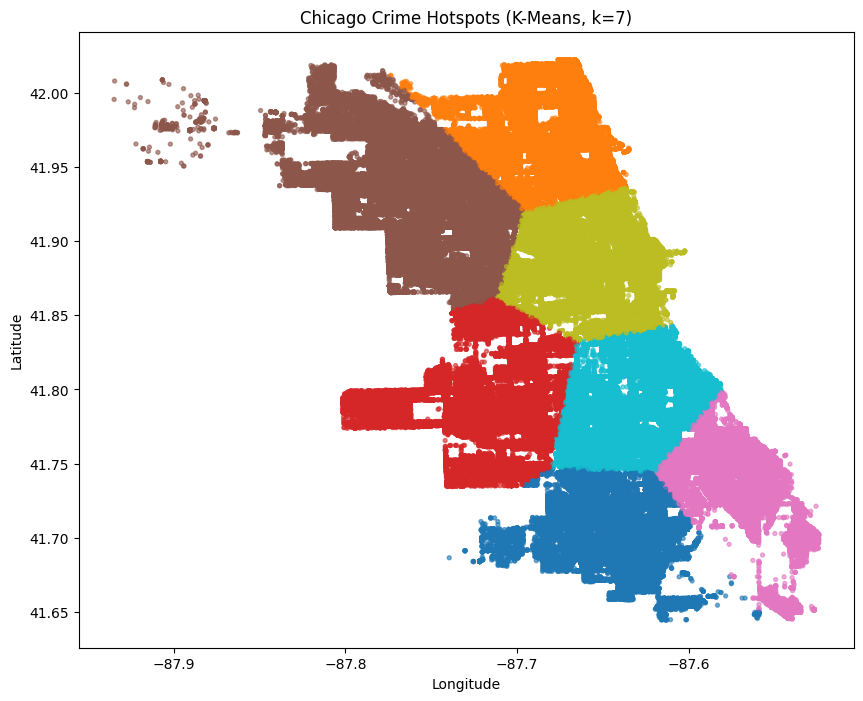

In [8]:
plt.figure(figsize=(10,8))
plt.scatter(df['longitude'], df['latitude'], 
            c=labels, cmap='tab10', s=8, alpha=0.6)
plt.title(f"Chicago Crime Hotspots (K-Means, k=7)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

DBSCAN clustering

In [5]:
mlflow.set_experiment("Crime Hotspot Clustering V1")
mlflow.set_tracking_uri("http://127.0.0.1:5000/")

sample_df = df.sample(n=60000, random_state=42)
X_geo_dbscan = sample_df[['latitude', 'longitude']]

with mlflow.start_run(run_name="DBSCAN_Geo_Clustering"):
    dbscan = DBSCAN(eps=0.02, min_samples=50)
    labels = dbscan.fit_predict(X_geo_dbscan)

    valid_labels = labels[labels != -1]
    valid_points = X_geo_dbscan[labels != -1]

    sil_score = silhouette_score(valid_points, valid_labels) if len(set(valid_labels)) > 1 else -1
    db_score = davies_bouldin_score(valid_points, valid_labels) if len(set(valid_labels)) > 1 else -1

    mlflow.log_param("algorithm", "DBSCAN")
    mlflow.log_param("eps", 0.02)
    mlflow.log_param("min_samples", 20)

    mlflow.log_metric("silhouette_score", sil_score)
    mlflow.log_metric("davies_bouldin_score", db_score)

    # Log model
    mlflow.sklearn.log_model(dbscan, "dbscan_geo_model")

    results.append(("DBSCAN", sil_score, db_score))
    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"Davies-Bouldin index: {db_score:.4f}")

2025/11/09 21:14:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/09 21:14:55 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2025/11/09 21:14:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Silhouette Score: 0.4945
Davies-Bouldin index: 0.3807
🏃 View run DBSCAN_Geo_Clustering at: http://127.0.0.1:5000/#/experiments/497083060675887000/runs/cfcb4eb9245449de9f0d9665e991251d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/497083060675887000


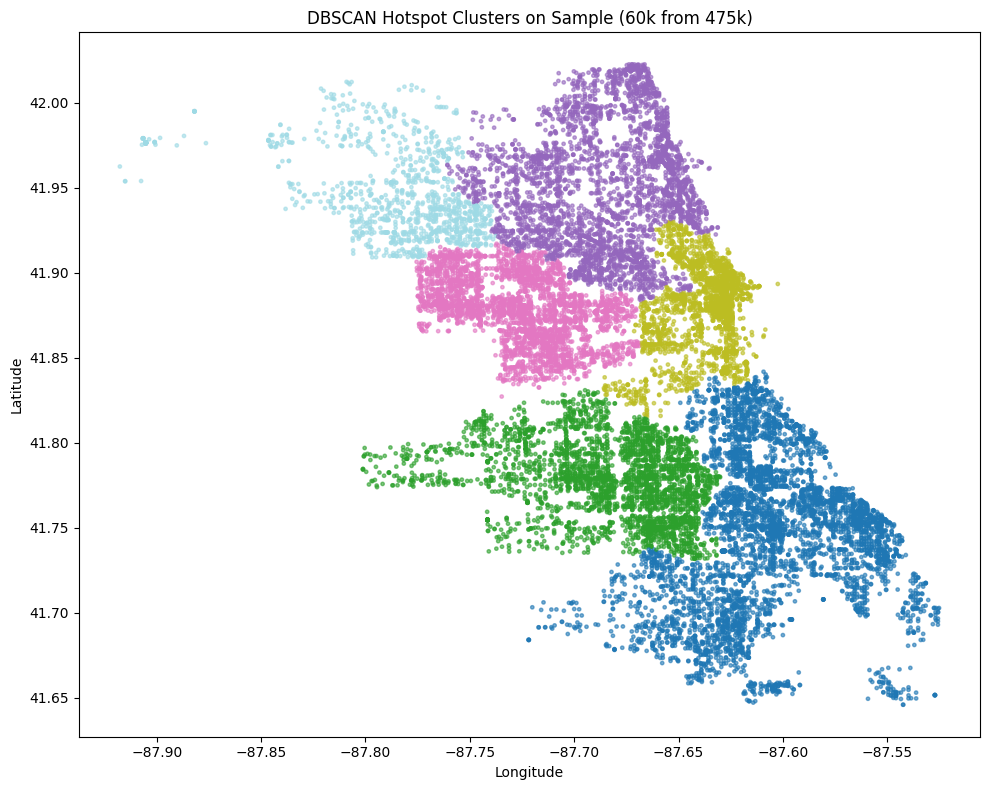

In [12]:
plt.figure(figsize=(10,8))
plt.scatter(sample_df['longitude'], sample_df['latitude'], c=labels, cmap='tab20', s=6, alpha=0.6)
plt.title("DBSCAN Hotspot Clusters on Sample (60k from 475k)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [ ]:
sns.scatterplot(
    x='Longitude_norm', y='Latitude_norm',
    hue='DBSCAN_Cluster', palette='tab20', data=df,
    legend='full', alpha=0.6
)
plt.title("DBSCAN Crime Hotspot Clusters in Chicago")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

Hierarichal clustering

In [10]:
mlflow.set_experiment("Crime Hotspot Clustering V1")
mlflow.set_tracking_uri("http://127.0.0.1:5000/")

sample_df = df.sample(n=20000, random_state=42)
X_geo = sample_df[['latitude', 'longitude']]

with mlflow.start_run(run_name="Hierarchical_Geo_Clustering"):
    hierarchical = AgglomerativeClustering(n_clusters=6)
    labels = hierarchical.fit_predict(X_geo)

    sil_score = silhouette_score(X_geo, labels)
    db_score = davies_bouldin_score(X_geo, labels)

    mlflow.log_param("algorithm", "Hierarchical")
    mlflow.log_param("n_clusters", 6)

    mlflow.log_metric("silhouette_score", sil_score)
    mlflow.log_metric("davies_bouldin_score", db_score)

    # Log model
    mlflow.sklearn.log_model(hierarchical, "hierarchical_geo_model")

    results.append(("Hierarchical", sil_score, db_score))
    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"Davies-Bouldin index: {db_score:.4f}")

2025/11/09 21:24:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/09 21:24:02 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2025/11/09 21:24:05 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Silhouette Score: 0.3433
Davies-Bouldin index: 0.8923
🏃 View run Hierarchical_Geo_Clustering at: http://127.0.0.1:5000/#/experiments/497083060675887000/runs/0abdcf9e87d0438aa470025b56711f65
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/497083060675887000


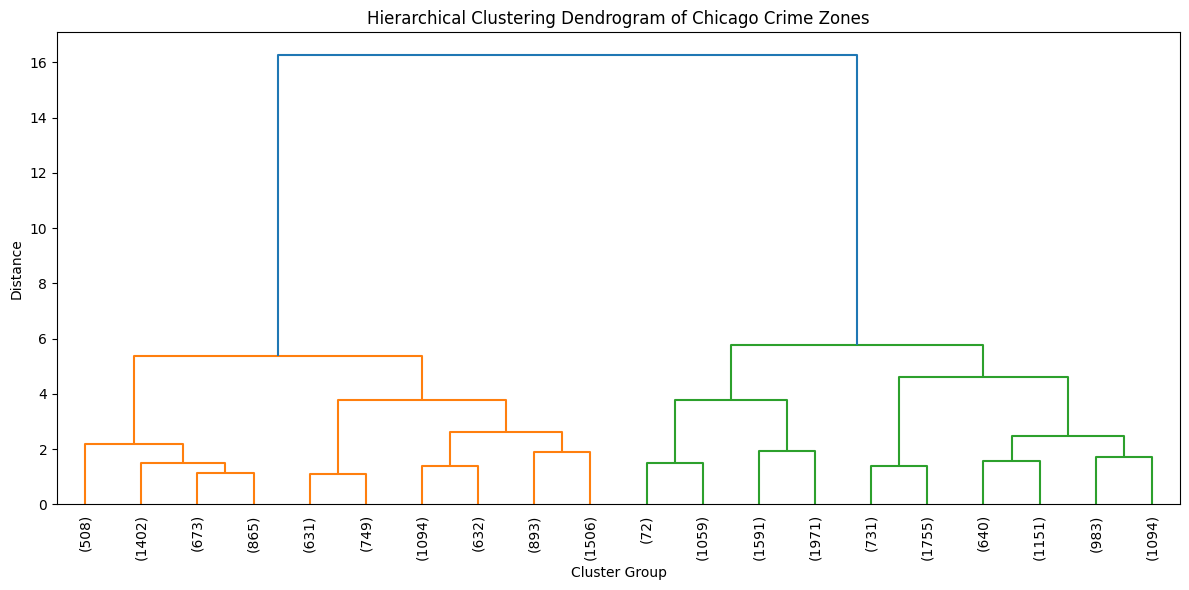

In [11]:
# Apply hierarchical clustering using Ward linkage
linked = linkage(X_geo, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=20, leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering Dendrogram of Chicago Crime Zones")
plt.xlabel("Cluster Group")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


In [13]:
best_model = max(results, key=lambda x: x[1])  # Based on silhouette score
print(f"✅ Best Model: {best_model[0]} | Silhouette: {round(best_model[1], 3)} | DB Index: {round(best_model[2], 3)}")

✅ Best Model: DBSCAN | Silhouette: 0.495 | DB Index: 0.381


Temporal crime patiern clustering

In [22]:
temporal_features = df[['hour', 'day_of_week', 'month']]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(temporal_features)

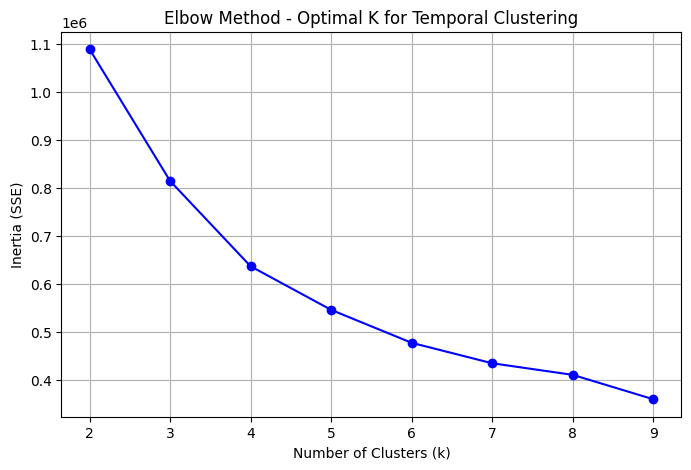

In [23]:
inertias = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertias, 'bo-')
plt.title("Elbow Method - Optimal K for Temporal Clustering")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (SSE)")
plt.grid(True)
plt.show()

In [24]:
best_k = 4
kmeans_temp = KMeans(n_clusters=best_k, random_state=42)
df['temporal_cluster'] = kmeans_temp.fit_predict(X_scaled)

# Evaluate cluster quality
sil = silhouette_score(X_scaled, df['temporal_cluster'])
dbi = davies_bouldin_score(X_scaled, df['temporal_cluster'])
print(f"✅ Silhouette Score: {sil:.4f} | Davies-Bouldin Index: {dbi:.4f}")

✅ Silhouette Score: 0.2831 | Davies-Bouldin Index: 1.0785


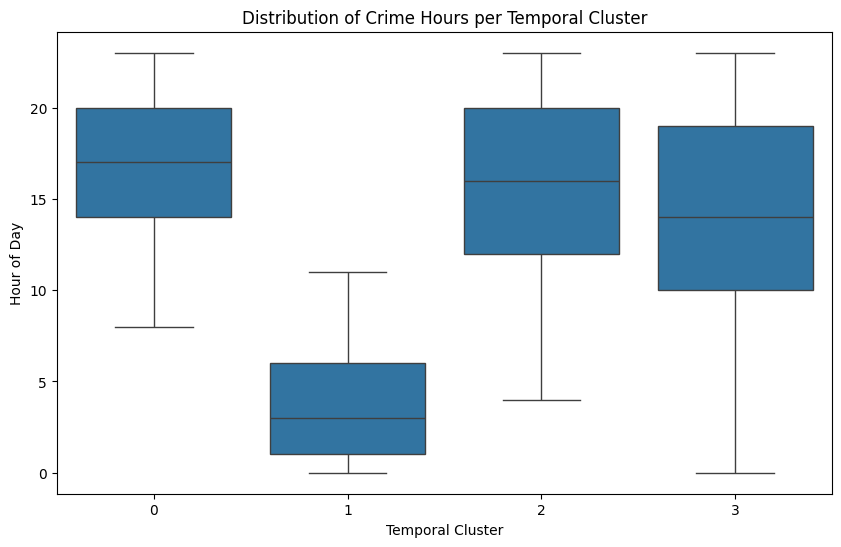

In [26]:
plt.figure(figsize=(10,6))
sns.boxplot(x='temporal_cluster', y='hour', data=df)
plt.title("Distribution of Crime Hours per Temporal Cluster")
plt.xlabel("Temporal Cluster")
plt.ylabel("Hour of Day")
plt.show()